In [1]:
# Imports & configuration

import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 50)


In [2]:
# Chargement des données

df = pd.read_csv("../datasets/transactions_50000.csv", parse_dates=["timestamp"])
df.head()


,order_id,user_id,event_id,timestamp,nb_tickets,montant,velocity_seconds,is_fraud
0,aaed9bfe-7236-4689-9fc6-741a0dbece2b,a91b1faa-818e-4203-8239-31e783e48d70,5627f9ab-fc29-43e2-a85e-94f1d445a66c,2025-01-01 00:00:37,3,309,33.810968,0
1,5612b999-a331-44c4-a790-ed90895e610e,63aa7929-6bb2-454a-b2a0-49c8a39a4a6b,36ed8e8a-a7cb-47dd-96a5-17b5fb98f2c7,2025-01-01 00:19:12,3,165,131.372129,0
2,fa48eb0b-5093-476a-9f23-267c036fff66,c3aa994e-1bdd-49f6-98b2-5cebd8302a51,3fa7683f-bce7-4f97-a9bc-358e518dc319,2025-01-01 01:01:56,1,128,5.852311,0
3,b0d812d3-13d2-4283-b44c-e8ac862b0fbb,75016216-5c60-42d3-8f02-b91e39ed0839,a6a50633-3e55-4873-bc45-86aafc8fa1fe,2025-01-01 01:09:33,1,53,247.619547,0
4,4100fea3-ed4f-4153-9823-aa0c65611ce9,56f47b1b-acfa-4db9-a72b-70723a35200b,a6a50633-3e55-4873-bc45-86aafc8fa1fe,2025-01-01 01:23:24,2,106,75.959480,0


In [3]:
# Feature engineering (niveau utilisateur)

df = df.sort_values(["user_id", "timestamp"])

# Temps entre commandes
df["delta_seconds"] = df.groupby("user_id")["timestamp"].diff().dt.total_seconds()
df["delta_seconds"] = df["delta_seconds"].fillna(999999)

# Agrégation par utilisateur
user_features = df.groupby("user_id").agg(
    nb_commandes=("order_id", "count"),
    montant_total=("montant", "sum"),
    montant_moyen=("montant", "mean"),
    nb_tickets_total=("nb_tickets", "sum"),
    nb_tickets_moyen=("nb_tickets", "mean"),
    delta_moyen=("delta_seconds", "mean"),
    delta_min=("delta_seconds", "min"),
    delta_25=("delta_seconds", lambda x: np.percentile(x, 25)),
    delta_75=("delta_seconds", lambda x: np.percentile(x, 75)),
).reset_index()

user_features.head()


,user_id,nb_commandes,montant_total,montant_moyen,nb_tickets_total,nb_tickets_moyen,delta_moyen,delta_min,delta_25,delta_75
0,00056817-958d-42a7-b587-ebde5ddaa4cc,6,604,100.666667,9,1.500000,4.655968e+06,999999.0,1767524.25,6117717.00
1,00140548-6eba-4dc0-be45-35bd60361be5,7,540,77.142857,9,1.285714,4.135537e+06,999999.0,2117809.00,5732686.50
2,0015e1e4-273b-4e86-80fc-8509491336d7,9,1558,173.111111,16,1.777778,3.315335e+06,999999.0,1328109.00,4826324.00
3,001c042a-9fed-4563-a205-47c0b6cb0c9c,6,1230,205.000000,12,2.000000,5.626651e+06,882238.0,1606197.25,6908140.25
4,001f1c61-b6aa-40b7-809a-a1c69d0ea784,4,370,92.500000,5,1.250000,1.493431e+06,304115.0,826028.00,1753199.25


In [4]:
# Préparation des features pour K-Means

feature_cols = [
    "nb_commandes",
    "montant_total",
    "montant_moyen",
    "nb_tickets_total",
    "nb_tickets_moyen",
    "delta_moyen",
    "delta_min",
    "delta_25",
    "delta_75"
]

X = user_features[feature_cols].copy()

# Log-transform pour réduire les écarts
for col in ["montant_total", "nb_commandes", "nb_tickets_total", "delta_moyen", "delta_min"]:
    X[col] = np.log1p(X[col])

# Standardisation
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


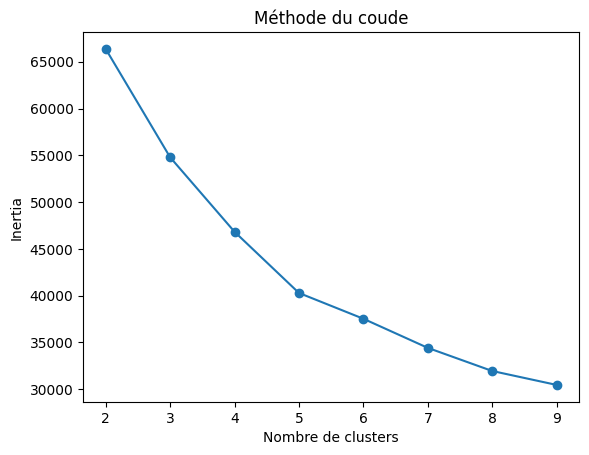

In [5]:
# Méthode du coude (choix du nombre de clusters)

inertias = []
K_range = range(2, 10)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.plot(K_range, inertias, marker='o')
plt.title("Méthode du coude")
plt.xlabel("Nombre de clusters")
plt.ylabel("Inertia")
plt.show()


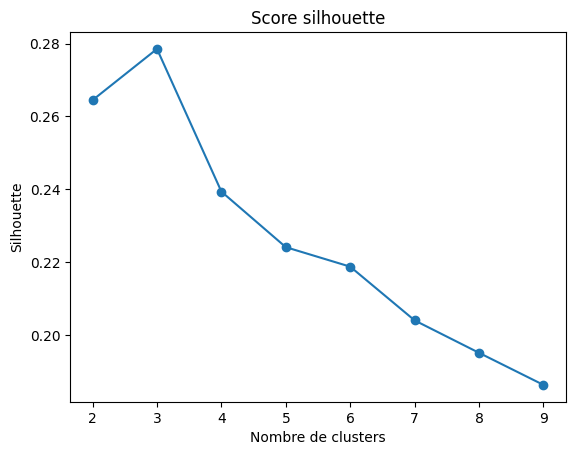

[0.2644799938600705,
 0.2785250741073017,
 0.23938623454117217,
 0.22415057540839212,
 0.21879920576650294,
 0.2040642511961259,
 0.19516579543589668,
 0.1863684163973962]

In [6]:
# Score silhouette (validation)

sil_scores = []

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42)
    labels = km.fit_predict(X_scaled)
    sil = silhouette_score(X_scaled, labels)
    sil_scores.append(sil)

plt.plot(K_range, sil_scores, marker='o')
plt.title("Score silhouette")
plt.xlabel("Nombre de clusters")
plt.ylabel("Silhouette")
plt.show()

sil_scores


In [7]:
# Entraînement final du K-Means

k = 4
kmeans = KMeans(n_clusters=k, random_state=42)
user_features["cluster"] = kmeans.fit_predict(X_scaled)

user_features.head()


,user_id,nb_commandes,montant_total,montant_moyen,nb_tickets_total,nb_tickets_moyen,delta_moyen,delta_min,delta_25,delta_75,cluster
0,00056817-958d-42a7-b587-ebde5ddaa4cc,6,604,100.666667,9,1.500000,4.655968e+06,999999.0,1767524.25,6117717.00,2
1,00140548-6eba-4dc0-be45-35bd60361be5,7,540,77.142857,9,1.285714,4.135537e+06,999999.0,2117809.00,5732686.50,2
2,0015e1e4-273b-4e86-80fc-8509491336d7,9,1558,173.111111,16,1.777778,3.315335e+06,999999.0,1328109.00,4826324.00,2
3,001c042a-9fed-4563-a205-47c0b6cb0c9c,6,1230,205.000000,12,2.000000,5.626651e+06,882238.0,1606197.25,6908140.25,3
4,001f1c61-b6aa-40b7-809a-a1c69d0ea784,4,370,92.500000,5,1.250000,1.493431e+06,304115.0,826028.00,1753199.25,1


In [8]:
# Analyse des clusters

cluster_summary = user_features.groupby("cluster")[feature_cols].mean()
cluster_summary


,nb_commandes,montant_total,montant_moyen,nb_tickets_total,nb_tickets_moyen,delta_moyen,delta_min,delta_25,delta_75
cluster,,,,,,,,,
0,3.478396,397.339432,116.232600,4.951732,1.444531,6.894933e+06,954075.736084,3.124920e+06,9.832006e+06
1,1.852055,198.223288,110.505571,2.547945,1.428196,1.659455e+06,915496.041096,1.214326e+06,2.027716e+06
2,6.637646,913.180957,136.793683,10.862905,1.630494,3.837891e+06,531446.616707,1.223686e+06,5.008136e+06
3,4.554817,1002.035121,226.193099,10.823446,2.426672,4.967812e+06,853680.809682,1.984430e+06,6.794135e+06


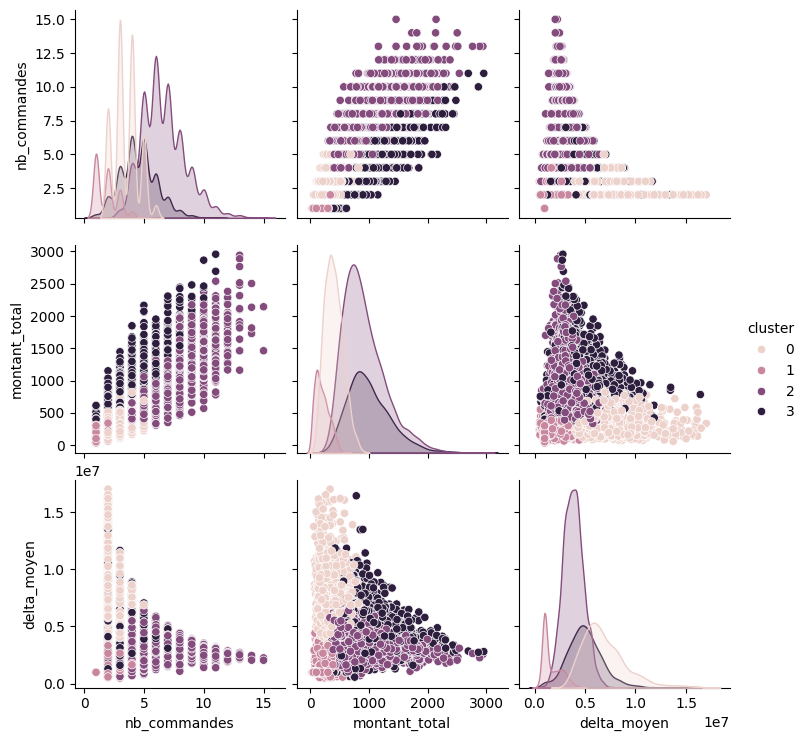

In [9]:
# Visualisation rapide 
sns.pairplot(user_features, hue="cluster", vars=["nb_commandes", "montant_total", "delta_moyen"])
plt.show()


In [10]:
# Interprétation automatique des clusters

def describe_cluster(df, cluster_id):
    subset = df[df["cluster"] == cluster_id]
    return {
        "cluster": cluster_id,
        "nb_users": len(subset),
        "panier_moyen": subset["montant_moyen"].mean(),
        "freq_achat": subset["nb_commandes"].mean(),
        "delta_moyen": subset["delta_moyen"].mean()
    }

descriptions = [describe_cluster(user_features, c) for c in sorted(user_features["cluster"].unique())]
descriptions


[{'cluster': np.int32(0),
  'nb_users': 2569,
  'panier_moyen': np.float64(116.23260023355392),
  'freq_achat': np.float64(3.4783962631374075),
  'delta_moyen': np.float64(6894933.477857793)},
 {'cluster': np.int32(1),
  'nb_users': 730,
  'panier_moyen': np.float64(110.50557077625571),
  'freq_achat': np.float64(1.8520547945205479),
  'delta_moyen': np.float64(1659455.490547945)},
 {'cluster': np.int32(2),
  'nb_users': 4537,
  'panier_moyen': np.float64(136.7936834251635),
  'freq_achat': np.float64(6.637646021600176),
  'delta_moyen': np.float64(3837891.3769070827)},
 {'cluster': np.int32(3),
  'nb_users': 2107,
  'panier_moyen': np.float64(226.19309883018946),
  'freq_achat': np.float64(4.554817275747508),
  'delta_moyen': np.float64(4967812.321218233)}]

In [11]:
# Export vers CSV (pour intégration backend / PostgreSQL)

output_path = "../datasets/user_segmentation.csv"
user_features.to_csv(output_path, index=False)

print("Segmentation exportée :", output_path)
print("Nombre d'utilisateurs :", len(user_features))


Segmentation exportée : ../datasets/user_segmentation.csv
Nombre d'utilisateurs : 9943
